<a href="https://colab.research.google.com/github/KweonTJ/Artifical_Intelligence-ML-NN-/blob/main/lec09_backpropagation_student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 역전파 (Backpropagation) 실습

이 실습에서는 신경망의 핵심 알고리즘인 역전파(Backpropagation)를 직접 구현합니다:
1. Sigmoid 활성화 함수
2. 순전파 (Forward Propagation)
3. 역전파 (Backward Propagation)
4. XOR 문제 학습

**신경망 구조:**
- 입력층: 2개 뉴런
- 은닉층: 2개 뉴런 (Sigmoid)
- 출력층: 1개 뉴런 (Sigmoid)

**총점: 100점**

**학번:** 2023042028\
**이름:** 권택주

---
## Part 1: 데이터셋 준비 (5점)

XOR 문제의 데이터셋을 준비합니다.

| x1 | x2 | y (XOR) |
|----|----|------|
| 0  | 0  | 0    |
| 0  | 1  | 1    |
| 1  | 0  | 1    |
| 1  | 1  | 0    |

---

In [2]:
#@title { vertical-output: true}
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(4)

# XOR Dataset
X = np.array([[0, 0, 1, 1],
              [0, 1, 0, 1]])  # 2x4 (2 features, 4 samples)
y = np.array([[0, 1, 1, 0]])  # 1x4 (XOR output)

print(f"입력 데이터 X shape: {X.shape}")
print(f"출력 데이터 y shape: {y.shape}")
print(f"\nXOR 진리표:")
for i in range(X.shape[1]):
    print(f"  {X[0,i]} XOR {X[1,i]} = {y[0,i]}")

입력 데이터 X shape: (2, 4)
출력 데이터 y shape: (1, 4)

XOR 진리표:
  0 XOR 0 = 0
  0 XOR 1 = 1
  1 XOR 0 = 1
  1 XOR 1 = 0


---
## Part 2: 활성화 함수 (15점)

Sigmoid 활성화 함수를 구현합니다.

**Sigmoid 함수:** $\sigma(z) = \frac{1}{1 + e^{-z}}$

---

### 문제 2-1. Sigmoid 함수 구현 [15점]

**문제:** Sigmoid 함수를 구현하세요.

**힌트:** `1 / (1 + np.exp(-z))`

**예상 결과:**
```
sigmoid(0) = 0.5
sigmoid(2) ≈ 0.88
sigmoid(-2) ≈ 0.12
```

sigmoid(0) = 0.5000
sigmoid(2) = 0.8808
sigmoid(-2) = 0.1192


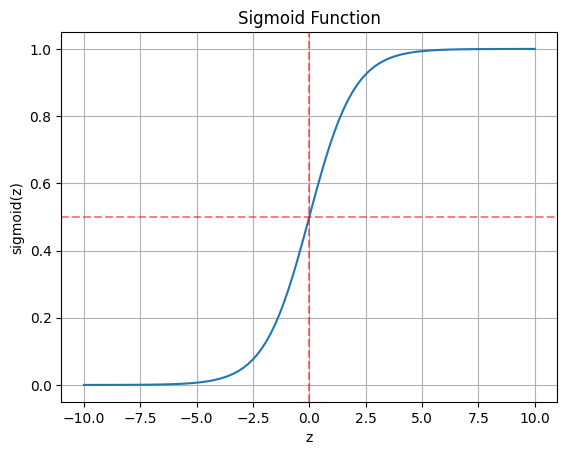

In [9]:
#@title { vertical-output: true}
def sigmoid(z):
    """
    Sigmoid 활성화 함수

    Parameters:
    - z: 입력값 (스칼라 또는 배열)

    Returns:
    - sigmoid(z): 0과 1 사이의 값
    """
    # IMPLEMENT HERE

    return 1 / (1 + np.exp(-z))

# 테스트
print(f"sigmoid(0) = {sigmoid(0):.4f}")
print(f"sigmoid(2) = {sigmoid(2):.4f}")
print(f"sigmoid(-2) = {sigmoid(-2):.4f}")

# 시각화
z = np.linspace(-10, 10, 100)
plt.plot(z, sigmoid(z))
plt.xlabel('z')
plt.ylabel('sigmoid(z)')
plt.title('Sigmoid Function')
plt.grid(True)
plt.axhline(y=0.5, color='r', linestyle='--', alpha=0.5)
plt.axvline(x=0, color='r', linestyle='--', alpha=0.5)
plt.show()

---
## Part 3: 순전파 (Forward Propagation) (25점)

입력에서 출력까지의 순전파를 구현합니다.

**순전파 수식:**
- 은닉층: $z_1 = W_1 \cdot X + b_1$, $h_1 = \sigma(z_1)$
- 출력층: $z_2 = W_2 \cdot h_1 + b_2$, $\hat{y} = \sigma(z_2)$

---

### 문제 3-1. Forward Propagation 구현 [25점]

**문제:** 순전파 함수를 구현하세요.

**힌트:**
```python
z1 = w1 @ x + b1
h1 = sigmoid(z1)
z2 = w2 @ h1 + b2
y_hat = sigmoid(z2)
```

**예상 결과:** z1, h1, z2, y_hat 반환

In [10]:
#@title { vertical-output: true}
def forward_prop(w1, w2, b1, b2, x):
    """
    순전파 (Forward Propagation)

    Parameters:
    - w1: 은닉층 가중치 (n_h x n_x)
    - w2: 출력층 가중치 (n_y x n_h)
    - b1: 은닉층 편향 (n_h x 1)
    - b2: 출력층 편향 (n_y x 1)
    - x: 입력 데이터 (n_x x m)

    Returns:
    - z1, h1, z2, y_hat
    """
    # IMPLEMENT HERE: 은닉층
    z1 = w1 @ x + b1
    h1 = sigmoid(z1)

    # IMPLEMENT HERE: 출력층
    z2 = w2 @ h1 + b2
    y_hat = sigmoid(z2)

    return z1, h1, z2, y_hat

# 테스트용 임시 가중치로 검증
w1_test = np.array([[0.5, 0.5], [0.5, 0.5]])
w2_test = np.array([[0.5, 0.5]])
b1_test = np.zeros((2, 1))
b2_test = np.zeros((1, 1))

z1_t, h1_t, z2_t, y_hat_t = forward_prop(w1_test, w2_test, b1_test, b2_test, X)
print(f"y_hat shape: {y_hat_t.shape}")
print(f"y_hat 값: {y_hat_t.flatten()}")

y_hat shape: (1, 4)
y_hat 값: [0.62245933 0.65077768 0.65077768 0.67503753]


---
## Part 4: 역전파 (Backward Propagation) (30점)

그래디언트를 계산하는 역전파를 구현합니다.

**역전파 수식:**
- 출력층: $dz_2 = \hat{y} - y$, $dW_2 = dz_2 \cdot h_1^T$, $db_2 = \sum dz_2$
- 은닉층: $dz_1 = W_2^T \cdot dz_2 \odot h_1 \odot (1 - h_1)$, $dW_1 = dz_1 \cdot X^T$, $db_1 = \sum dz_1$

---

### 문제 4-1. Backward Propagation 구현 [30점]

**문제:** 역전파 함수를 구현하세요.

**힌트:**
```python
# 출력층 그래디언트
dz2 = y_hat - y
dw2 = dz2 @ h1.T
db2 = dz2 @ np.ones((m, 1))

# 은닉층 그래디언트
dz1 = w2.T @ dz2 * h1 * (1 - h1)
dw1 = dz1 @ x.T
db1 = dz1 @ np.ones((m, 1))
```

**예상 결과:** dw1, db1, dw2, db2 반환

In [11]:
#@title { vertical-output: true}
def back_prop(m, w1, w2, z1, h1, z2, y_hat, x, y):
    """
    역전파 (Backward Propagation)

    Parameters:
    - m: 샘플 개수
    - w1, w2: 가중치
    - z1, h1, z2, y_hat: 순전파 결과
    - x: 입력 데이터
    - y: 실제 레이블

    Returns:
    - dw1, db1, dw2, db2: 그래디언트
    """
    # IMPLEMENT HERE: 출력층 그래디언트
    dz2 = y_hat - y
    dw2 = dz2 @ h1.T
    db2 = dz2 @ np.ones((m, 1))

    # IMPLEMENT HERE: 은닉층 그래디언트
    dz1 = w2.T @ dz2 * h1 * (1 - h1)
    dw1 = dz1 @ x.T
    db1 = dz1 @ np.ones((m, 1))

    return dw1, db1, dw2, db2

print("back_prop 함수 정의 완료")

back_prop 함수 정의 완료


---
## Part 5: 가중치 초기화 (5점)

신경망의 가중치를 무작위로 초기화합니다.

---

### 문제 5-1. 가중치 초기화 [5점]

**문제:** 가중치와 편향을 초기화하세요.

**힌트:**
```python
w1 = np.random.rand(n_h, n_x)  # (2, 2)
w2 = np.random.rand(n_y, n_h)  # (1, 2)
b1 = np.random.rand(n_h, 1)    # (2, 1)
b2 = np.random.rand(n_y, 1)    # (1, 1)
```

**예상 결과:** 4개의 가중치/편향 행렬 초기화

In [5]:
#@title { vertical-output: true}
# 네트워크 구조 정의
n_x = 2  # 입력 뉴런 수
n_h = 2  # 은닉층 뉴런 수
n_y = 1  # 출력 뉴런 수

# IMPLEMENT HERE: 가중치 초기화
w1 = np.random.rand(n_h, n_x)  # 은닉층 가중치 (n_h x n_x)
w2 = np.random.rand(n_y, n_h)  # 출력층 가중치 (n_y x n_h)
b1 = np.random.rand(n_h, 1)  # 은닉층 편향 (n_h x 1)
b2 = np.random.rand(n_y, 1)  # 출력층 편향 (n_y x 1)

print(f"w1 shape: {w1.shape}")
print(f"w2 shape: {w2.shape}")
print(f"b1 shape: {b1.shape}")
print(f"b2 shape: {b2.shape}")

w1 shape: (2, 2)
w2 shape: (1, 2)
b1 shape: (2, 1)
b2 shape: (1, 1)


---
## Part 6: 학습 (Training) (15점)

순전파, 손실 계산, 역전파, 가중치 업데이트를 반복합니다.

**Binary Cross-Entropy 손실:**
$$L = -\frac{1}{m}\sum[y\log(\hat{y}) + (1-y)\log(1-\hat{y})]$$

---

### 문제 6-1. 학습 루프 구현 [15점]

**문제:** 학습 루프를 완성하세요.

**구현 순서:**
1. 순전파
2. 손실 계산
3. 역전파
4. 가중치 업데이트

**예상 결과:** 손실이 점점 감소하는 그래프

최종 손실: 0.002696

w1: [7.45239535 7.4485394  5.67564407 5.67490743]
w2: [ 12.98812417 -13.76741383]
b1: [-3.41219149 -8.67843908]
b2: [-6.09160319]


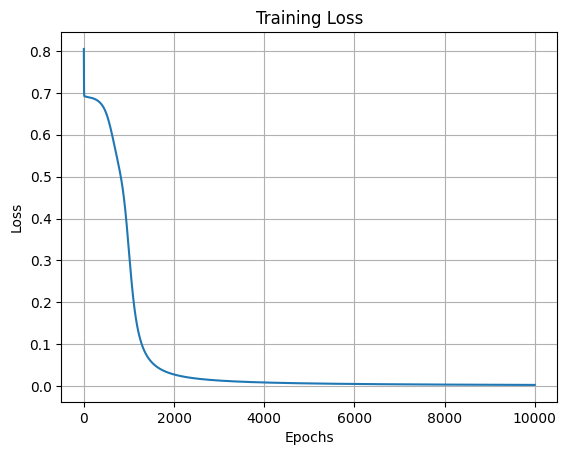

In [12]:
#@title { vertical-output: true}
# 하이퍼파라미터
epoch = 10000
lr = 0.1  # Learning rate
m = y.shape[1]  # 샘플 개수

losses = []

for i in range(epoch):
    # IMPLEMENT HERE: 순전파
    z1, h1, z2, y_hat = forward_prop(w1, w2, b1, b2, X)

    # IMPLEMENT HERE: Binary Cross-Entropy 손실 계산
    loss = -np.sum(y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat)) / m
    losses.append(loss)

    # IMPLEMENT HERE: 역전파
    dw1, db1, dw2, db2 = back_prop(m, w1, w2, z1, h1, z2, y_hat, X, y)

    # IMPLEMENT HERE: 가중치 업데이트
    w2 = w2 - lr * dw2
    b2 = b2 - lr * db2
    w1 = w1 - lr * dw1
    b1 = b1 - lr * db1

# 학습 결과 출력
print(f"최종 손실: {losses[-1]:.6f}")
print(f"\nw1: {w1.flatten()}")
print(f"w2: {w2.flatten()}")
print(f"b1: {b1.flatten()}")
print(f"b2: {b2.flatten()}")

# 손실 그래프
plt.plot(losses)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.grid(True)
plt.show()

---
## Part 7: 예측 및 시각화 (5점)

학습된 모델로 XOR 문제를 예측합니다.

---

### 문제 7-1. 예측 함수 및 결과 확인 [5점]

**예상 결과:**
```
[0 0] => 0
[0 1] => 1
[1 0] => 1
[1 1] => 0
```

In [13]:
#@title { vertical-output: true}
def predict(w1, w2, b1, b2, input_data):
    """
    학습된 모델로 예측
    """
    z1, h1, z2, y_hat = forward_prop(w1, w2, b1, b2, input_data)
    y_hat = np.squeeze(y_hat)

    if y_hat <= 0.5:
        return 0
    else:
        return 1

# XOR 테스트
print("XOR 예측 결과:")
for x_sample in X.T:
    pred = predict(w1, w2, b1, b2, x_sample.reshape(2, 1))
    print(f"  {x_sample} => {pred}")

XOR 예측 결과:
  [0 0] => 0
  [0 1] => 1
  [1 0] => 1
  [1 1] => 0


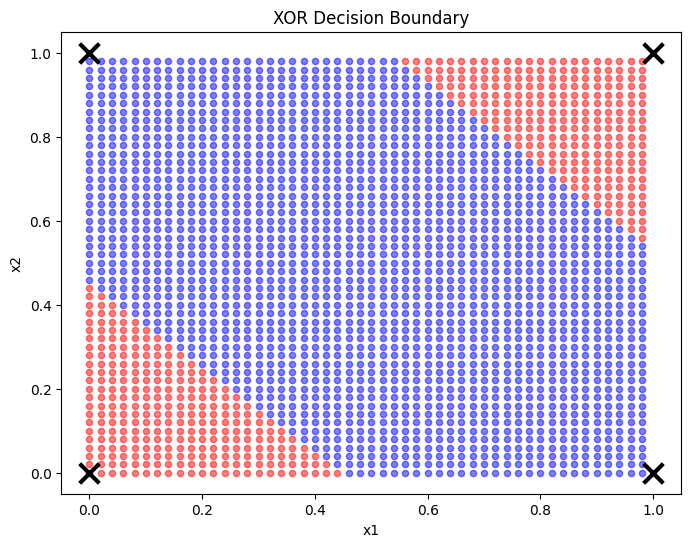

In [14]:
#@title { vertical-output: true}
# Decision Boundary 시각화
color = ['red', 'blue']
plt.figure(figsize=(8, 6))

for x0 in np.arange(0, 1, 0.02):
    for x1 in np.arange(0, 1, 0.02):
        x_test = np.array([x0, x1])
        y_pred = predict(w1, w2, b1, b2, x_test.reshape(2, 1))
        plt.scatter(x0, x1, c=color[y_pred], alpha=0.5, s=20)

# 원본 데이터 포인트 표시
for i in range(X.shape[1]):
    plt.scatter(X[0, i], X[1, i], c='black', s=200, marker='x', linewidths=3)

plt.xlabel('x1')
plt.ylabel('x2')
plt.title('XOR Decision Boundary')
plt.show()

---
## 제출 안내

1. 모든 문제를 완성한 후, 코드 셀을 실행하여 결과를 확인하세요.
2. **제출 파일:**
   - `.ipynb` 파일
   - `.pdf` 파일 (파일 > 인쇄 > PDF로 저장)
3. 파일명: `backpropagation_학번_이름.ipynb`, `backpropagation_학번_이름.pdf`
4. LMS에 두 파일을 함께 제출하세요.

**주의:** 기한 내에 제출하지 않으면 감점이 있습니다.

---